In [ ]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import (Material, Geometry, PhotonicCrystal, 
                                        ScriptParam, ScriptParamVector3, BaseDielectricDistribution,
                                        HexagonalLattice)
import meep as mp
from src.mpb_configurator import *
from src.mpi_differential_evolution import MPIdeOptimizator
from src.simulation_handler import LSFJobConfiguration, MPBDataOptions, Simulation
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.simulation_viewer import SimulationViewer
from src.sweeper import ParamSweeper

import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors

n_InP = 3.1
eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "C4v_diatomic"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice

lattice_2D = SquareLattice()
lattice_slab = SquareLattice(supercell_height= 4)

k_points = lattice_2D.get_high_symmetry_k_points(centered_in_gamma=False)
print(k_points)


center = mp.Vector3(0,0,0)


geom_2D = BaseDielectricDistribution().make_C4v_diatomic_B()
geom_slab = BaseDielectricDistribution(height_slab=0.5).make_C4v_diatomic_B()


photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=geom_slab)

## Define the simulation
configuration_options = dict(
    resolution = 32, 
    num_bands=12,
    k_points=k_points["k_points_values"],
    k_points_interpolation_factor = 10,
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-hfield-phase output-hfield)",
)

configuration_options_optimization = dict(
    resolution = 64, 
    num_bands=10,
    k_points = [mp.Vector3(0,0,0)],
    
)

configuration_options_sweep = dict( 
    resolution = 64,
    num_bands=10,
    k_points=[mp.Vector3(0,0,0)],
)


mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options)
mpb_configuration_2D_opt = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options_optimization)
mpb_configuration_slab_opt = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_optimization)
mpb_configuration_slab_sweep = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven"], **configuration_options_sweep)

script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)
script_2D_opt = mpb_configuration_2D_opt.get_scheme_config(join_newline=True)
script_slab_opt = mpb_configuration_slab_opt.get_scheme_config(join_newline=True)
script_slab_sweep = mpb_configuration_slab_sweep.get_scheme_config(join_newline=True)




name_2D = name  + "_2D"
name_slab = name + "_slab"
name_2D_opt = name + "_2D_opt"
name_slab_opt = name + "_slab_opt"
name_slab_sweep = name + "_slab_sweep"

data_rooth = "/work3/s232699/phc_nzi/data/"

simulation_2D = Simulation(
    simulation_name=name_2D,
    script = script_2D,
    directory= os.path.join(data_rooth, name_2D)
    )

simulation_2D_opt = Simulation(
    simulation_name=name_2D_opt,
    script = script_2D_opt,
    directory= os.path.join(data_rooth, name_2D_opt)
    )

simulation_slab = Simulation(
    simulation_name=name_slab,
    script = script_slab,
    directory= os.path.join(data_rooth, name_slab)
    )


simulation_slab_opt = Simulation(
    simulation_name=name_slab_opt,
    script = script_slab_opt,
    directory= os.path.join(data_rooth, name_slab_opt)  
    )

simulation_slab_sweep = Simulation(
    simulation_name=name_slab_sweep,
    script = script_slab_sweep,
    directory= os.path.join(data_rooth, name_slab_sweep)  
    )



numproc= 32
pop = numproc // 2
lsf_config = LSFJobConfiguration(num_processors=numproc, span_option="block", span_value=8, queue="fotonano")


Epsilon of InP:  9.61
{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<0.5, 0.0, 0.0>, Vector3<0.5, 0.5, 0.0>, Vector3<0.0, 0.0, 0.0>], 'k_points_labels': ['$\\Gamma$', 'X', 'M', '$\\Gamma$']}
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.5)', '(define-param r1 0.1)', '(define-param r2 0.2)']


2D simulation done


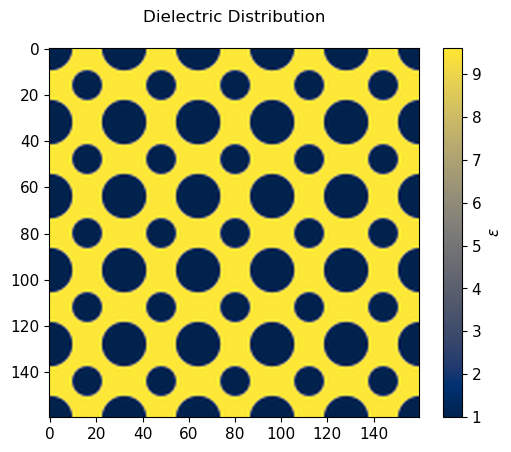

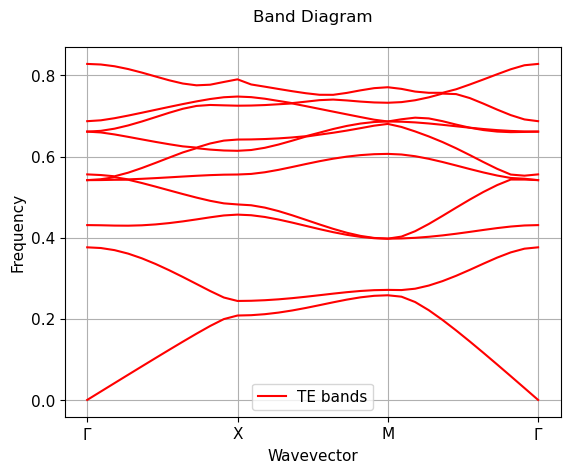

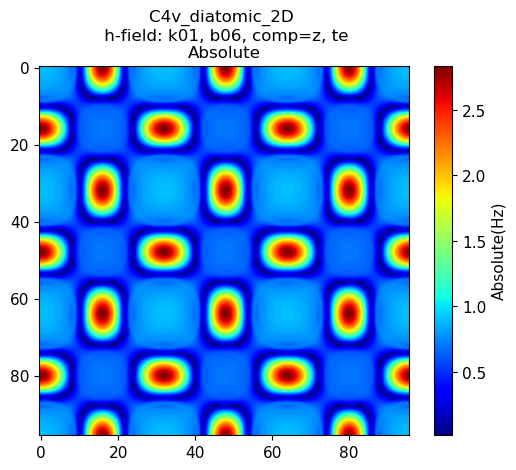

In [2]:

#simulation_2D.run_hpc(mpb_command_line_params=dict(r1 = 0.2, r2 = 0.3), mpi = True)
print("2D simulation done")
viewer_2D = SimulationViewer(simulation_2D) 
opt = MPBDataOptions(rectify=True, periods= 5)
viewer_2D.figure()
viewer_2D.plot_epsilon_2d(conversion_options=opt)
viewer_2D.show()

viewer_2D.plot_band_diagram("te", k_points_path=k_points, color = "red")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
viewer_2D.show()

viewer_2D.plot_field_2d(1, 6, "h", "z", "te", False, np.abs) 


<Figure size 640x480 with 0 Axes>

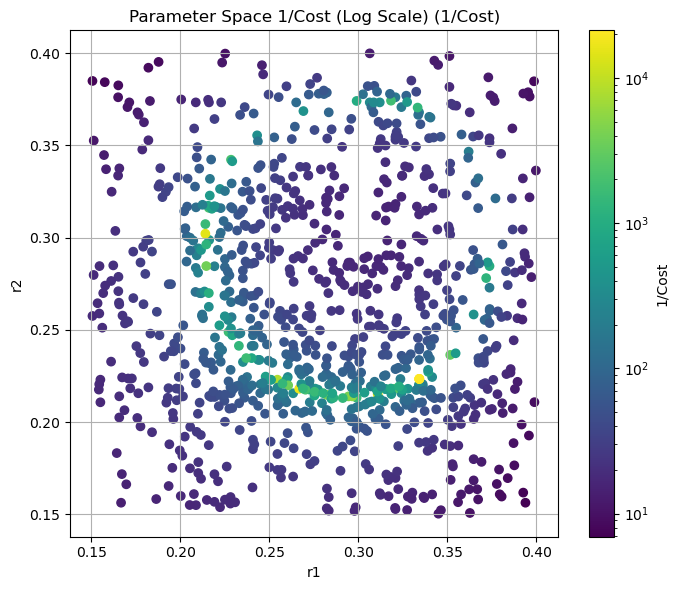

<Axes: title={'center': 'Fitted Ellipse'}, xlabel='r1', ylabel='r2'>

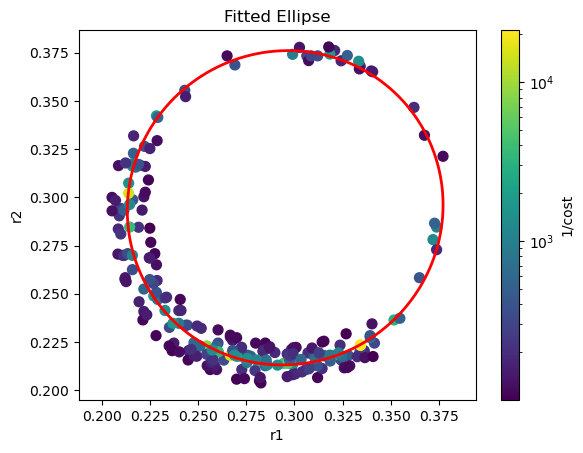

In [3]:
optimizer = MPIdeOptimizator(
        simulation_name=simulation_2D_opt.simulation_name,
        scheme_script=simulation_2D_opt.script, 
        maxiter=30,
        param_names=["r1", "r2"],
        param_bounds=[(0.15, 0.4), (0.15, 0.4)],
        polarization="te",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[4,5,6],
        directory=os.path.join(data_rooth, simulation_2D_opt.simulation_name),
    )
#optimizer.erease_data_file()
#optimizer.submit_lsf_job(lsf_config)

analyzer = OptimizationDataAnalyzer(optimizer.data_file)
plt.figure()
analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)
plt.grid()     
plt.show()

df = analyzer.get_points_above_treshold(100)


norm = colors.LogNorm(vmin=(1/df["cost"]).min(), vmax=(1/df["cost"]).max())
plt.scatter(df["r1"], df["r2"], c=1/df["cost"], cmap="viridis", norm=norm, s=50)
plt.colorbar(label="1/cost")
a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"])
analyzer.plot_ellipse_from_conic(*a)



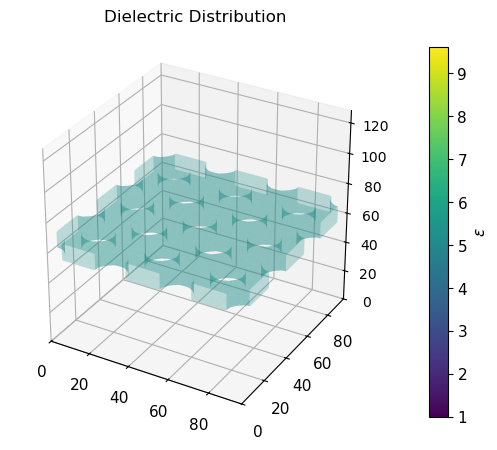

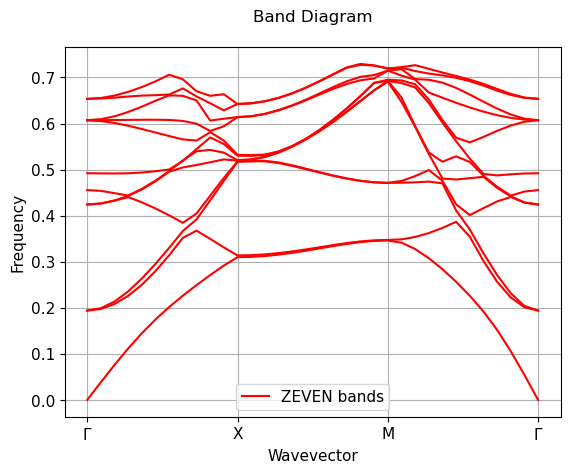

,k index,k1,k2,k3,kmag/2pi,zeven band 1,zeven band 2,zeven band 3,zeven band 4,zeven band 5,zeven band 6,zeven band 7,zeven band 8,zeven band 9,zeven band 10,zeven band 11,zeven band 12
0,1,0.000000,0.000000,0,0.000000,0.000000,0.193907,0.193954,0.424157,0.424170,0.455511,0.492047,0.606905,0.607219,0.607245,0.653525,0.653534
1,2,0.045455,0.000000,0,0.045455,0.038428,0.197534,0.199024,0.426260,0.426387,0.453841,0.491799,0.605344,0.607309,0.609438,0.654231,0.655400
2,3,0.090909,0.000000,0,0.090909,0.075976,0.208291,0.213503,0.432523,0.432960,0.448744,0.491515,0.601114,0.607519,0.615680,0.656116,0.660667
3,4,0.136364,0.000000,0,0.136364,0.111705,0.225889,0.235644,0.440228,0.442891,0.443668,0.491999,0.595104,0.607815,0.625039,0.658561,0.668700
4,5,0.181818,0.000000,0,0.181818,0.144739,0.249927,0.263488,0.428989,0.456980,0.458171,0.493628,0.588039,0.608102,0.636547,0.660614,0.679078
5,6,0.227273,0.000000,0,0.227273,0.174629,0.279716,0.295377,0.415569,0.474648,0.476038,0.496387,0.580429,0.608187,0.649412,0.661488,0.691555
6,7,0.272727,0.000000,0,0.272727,0.201589,0.314127,0.330075,0.400591,0.495389,0.496777,0.500169,0.572703,0.607672,0.661130,0.662996,0.705896
7,8,0.318182,0.000000,0,0.318182,0.226246,0.351853,0.366689,0.384453,0.504671,0.519825,0.518532,0.565574,0.605620,0.660091,0.676162,0.695925
8,9,0.363636,0.000000,0,0.363636,0.249217,0.367383,0.391808,0.404561,0.509976,0.539702,0.544497,0.563013,0.599548,0.650091,0.658883,0.670157
9,10,0.409091,0.000000,0,0.409091,0.270941,0.349562,0.433180,0.443144,0.515853,0.542693,0.569775,0.581111,0.583869,0.606326,0.643973,0.660189


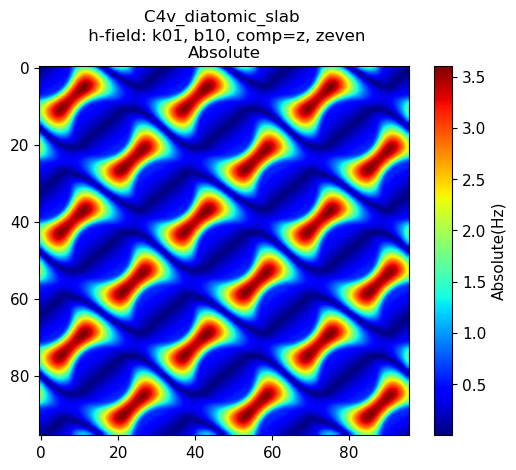

In [4]:

#lsf_config = LSFJobConfiguration(num_processors=4, span_option="hosts", span_value=1, queue="fotonano")
# import time
# time.sleep(1)
#simulation_slab.run_hpc_lsf(mpb_command_line_params=dict(r1 = 0.23, r2 = 0.24, h=0.35), LSFOptions=lsf_config)
viewer_slab = SimulationViewer(simulation_slab) 
opt = MPBDataOptions(rectify=True, periods=(3,3,1))
viewer_slab.figure()
viewer_slab.plot_epsilon_3d(conversion_options=opt)
viewer_slab.show()
viewer_slab.simulation.extract_frequencies()
viewer_slab.plot_band_diagram("zeven", k_points_path=k_points, color = "red")
#viewer_2D.plot_band_diagram("tm", k_points_path=k_points, color = "blue")
viewer_slab.show()
viewer_slab.plot_field_2d(1, 10, "h", "z", "zeven", False, np.abs) 
df = simulation_slab.load_frequency_data("zeven")
display(df)



In [5]:
# import concurrent.futures
# import time

# # Assume 'name' and 'script_slab' are defined elsewhere
# pop = numproc // 2
# h_array = [0.25, 0.3, 0.35, 0.4,0.45, 0.5, 0.55, 0.6]

# df_array= []
# def run_optimization(h):
#     opt_name = simulation_slab_opt.simulation_name + f"_p64_h_{h:0.3f}"
#     optimizer = MPIdeOptimizator(
#         simulation_name=opt_name,
#         scheme_script=simulation_slab_opt.script,
#         maxiter=15,
#         param_names=["r1", "r2"],
#         param_bounds=[(0.15, 0.35), (0.1, 0.35)],
#         polarization="zeven",
#         de_options={"strategy": "rand1bin", "popsize": pop},
#         bands=[8, 9, 10],
#         height_slab=h,
#         directory=os.path.join(data_rooth, opt_name)
#     )
#     # Submit the LSF job.
#     try:
#         #optimizer.erease_data_file()
#         pass
#     except:
#         pass
#     #optimizer.submit_lsf_job(lsf_config)
#     try:
#         data_file = optimizer.data_file
#         analyzer = OptimizationDataAnalyzer(data_file)
#         plt.figure()
#         analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)        
#         #plt.savefig(f"{optimizer.simulation.directory}/{opt_name}_raw_data_log_point.png")
#         plt.close()
#         plt.figure()
#         analyzer.plot_optimization_points_freq_dirac(points_only=True)
#         #plt.savefig(f"{optimizer.simulation.directory}/{opt_name}_freq_center.png")
#         plt.close()

#         df = analyzer.get_points_above_treshold(1200)
#         df["h"] = h
#         df_array.append(df)

#     except Exception as e:
#         print(f"An error occurred while analyzing the data: {e}")

# # Use ThreadPoolExecutor to run jobs concurrently with a small delay between job submissions.
# # with concurrent.futures.ThreadPoolExecutor() as executor:
# #     futures = []
# #     for h in h_array:
# #         futures.append(executor.submit(run_optimization, h))
# #         time.sleep(1)  # Add a small delay between submissions
# #     concurrent.futures.wait(futures)

<Figure size 640x480 with 0 Axes>

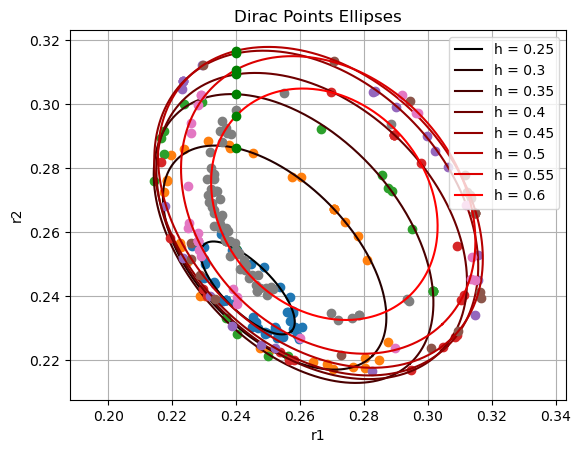

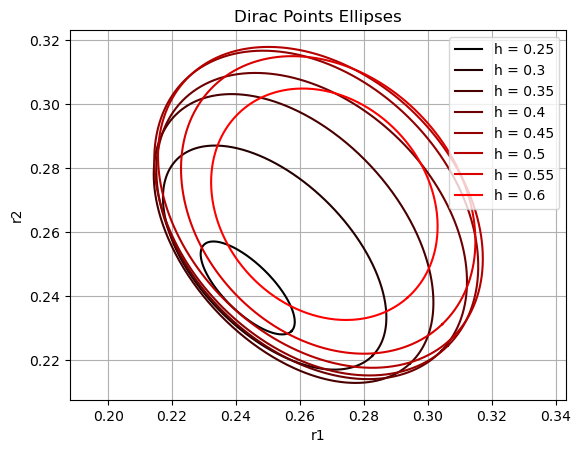

In [6]:
figure_ellipses = plt.figure()
figure_ellipses_no_point = plt.figure()
threshold = 1000
h_array = [0.25, 0.3, 0.35, 0.4,0.45, 0.5, 0.55, 0.6]
plt.figure(figure_ellipses)
for h in h_array:
    try:
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    df = analyzer.get_points_above_treshold(threshold)
    a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"]) 
    plt.plot(df["r1"], df["r2"], "o")
    analyzer.plot_ellipse_from_conic(*a, plot_kwds={"color": [h_norm , 0, 0], "label": f"h = {h}"})
    r1 = 0.24
    r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, a)
    plt.plot(r1, r2, "go")
plt.title(f"Dirac Points Ellipses")
plt.legend()
plt.grid()
plt.xlabel("r1")
plt.ylabel("r2")
plt.show()


plt.figure(figure_ellipses_no_point)
for h in h_array:
    try: 
        h_norm = (h - min(h_array)) / (max(h_array) - min(h_array))
    except:
        h_norm = 1
    path_data_file  = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_file)
    df = analyzer.get_points_above_treshold(threshold)
    a = analyzer.fit_ellipse(df["r1"], df["r2"], 1/df["cost"]) 
    plt.figure(figure_ellipses_no_point)
    analyzer.plot_ellipse_from_conic(*a, plot_kwds={"color": [h_norm , 0, 0], "label": f"h = {h}"})

plt.title(f"Dirac Points Ellipses")
plt.legend()
plt.grid()
plt.xlabel("r1")
plt.ylabel("r2")
plt.show()




In [7]:
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_0.350/{name_slab_opt}_p64_h_0.350.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
points = analyzer.get_points_above_treshold(1000)
#display(points)
print(analyzer.compute_param2_from_param1_on_ellipse(0.23,branch="lower", threshold=1000))

0.23965795349051427


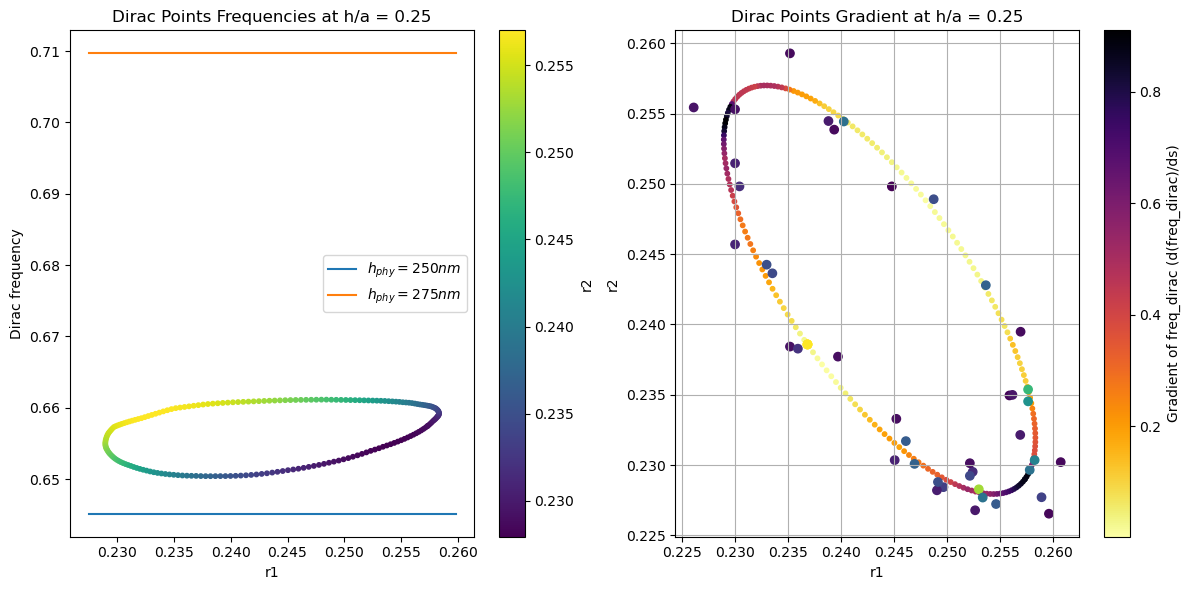

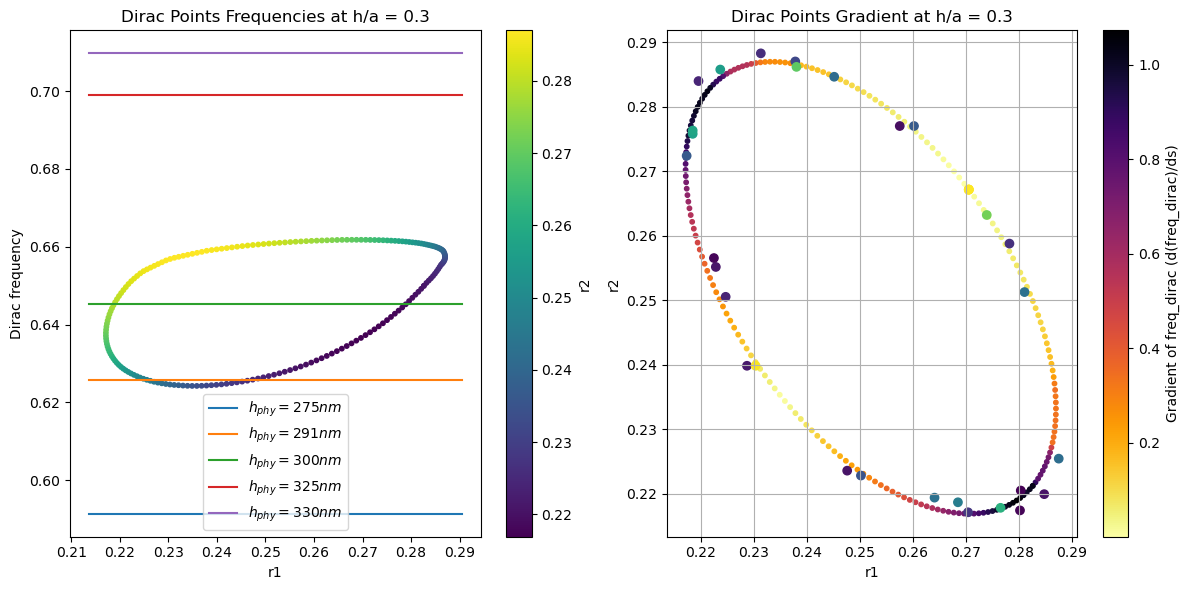

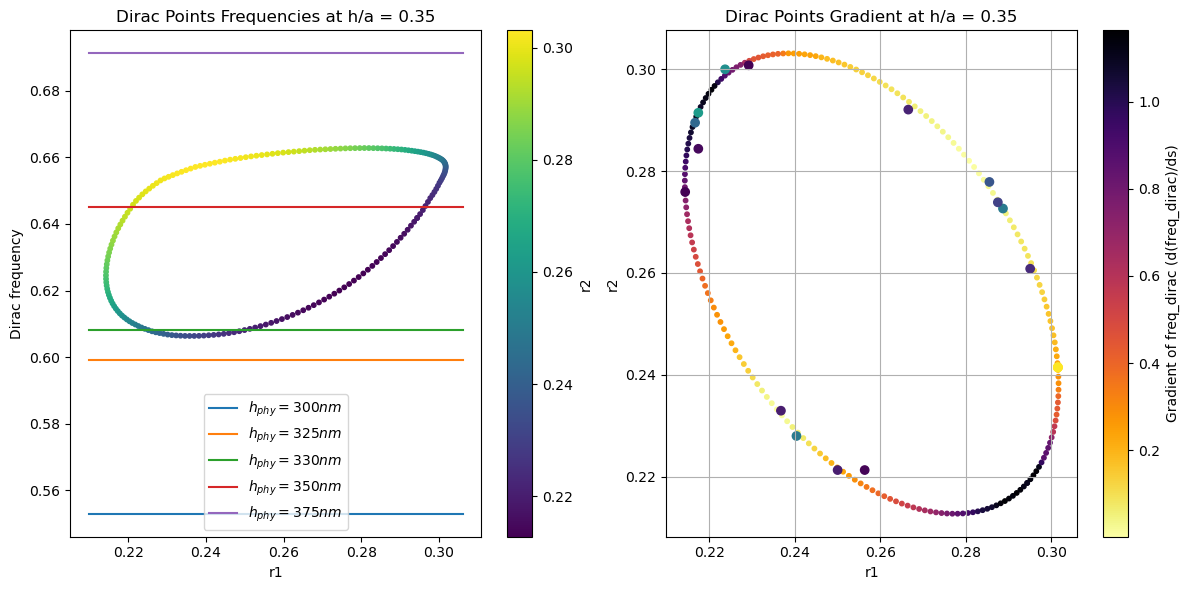

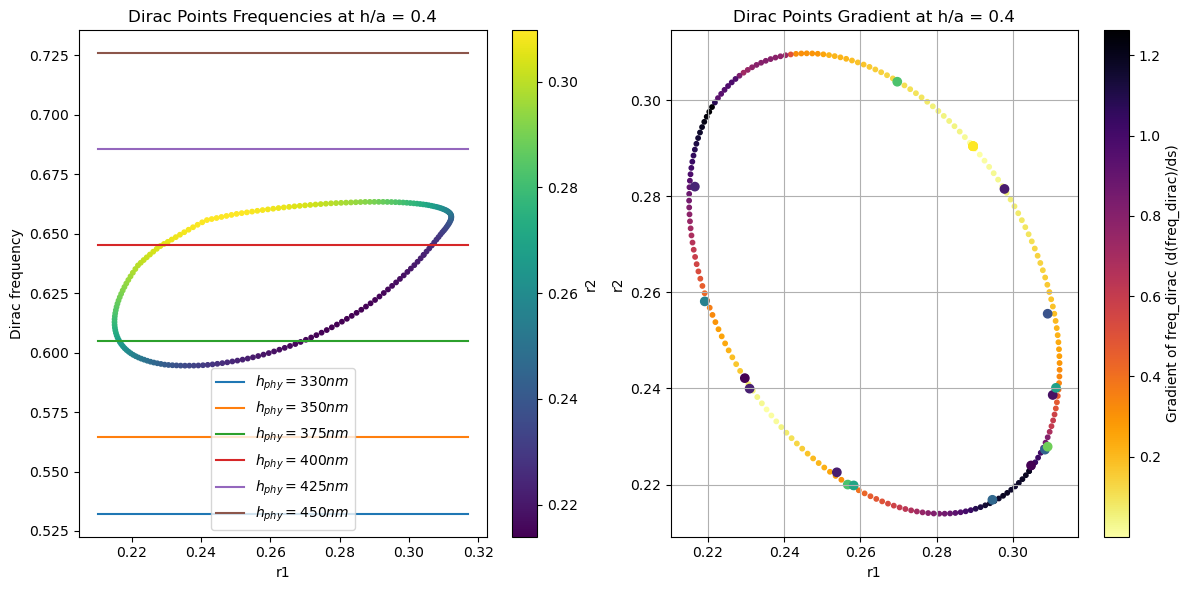

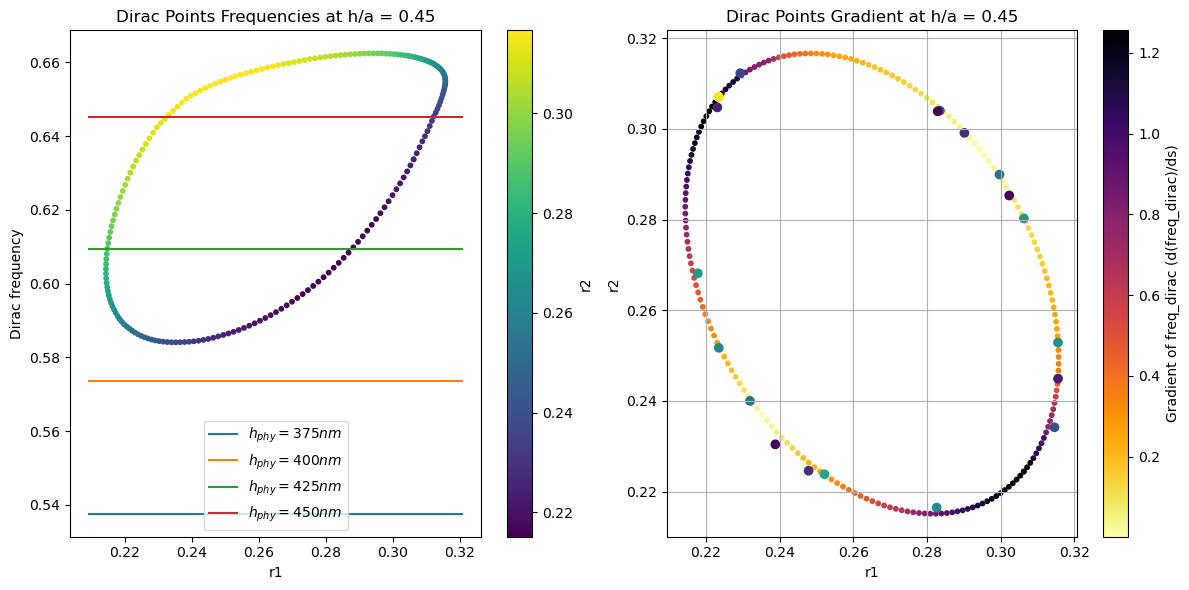

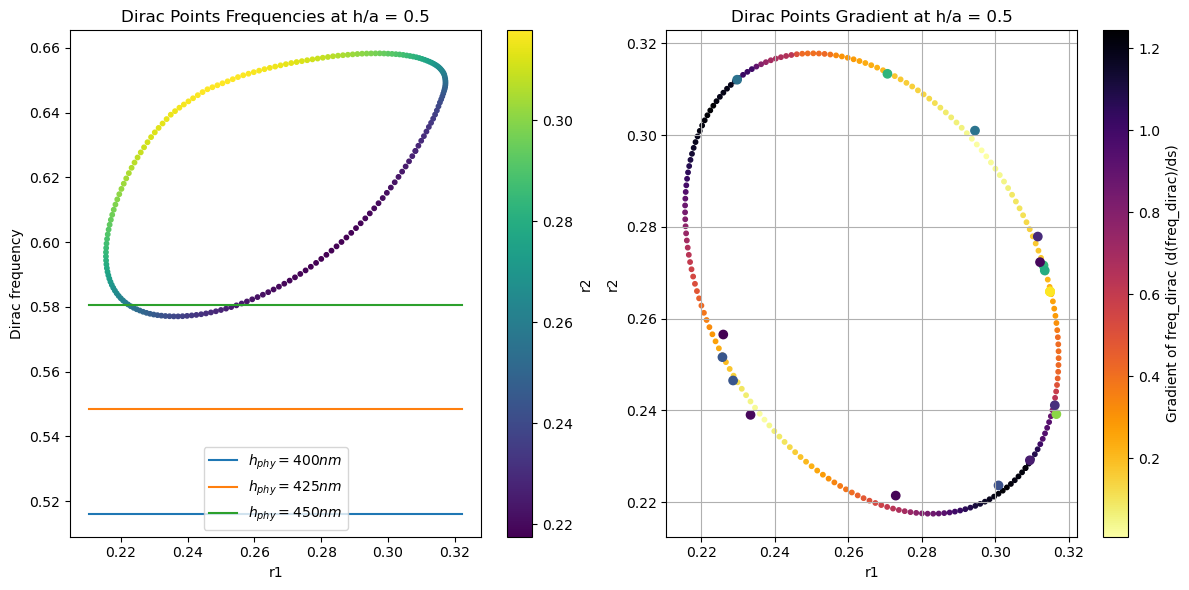

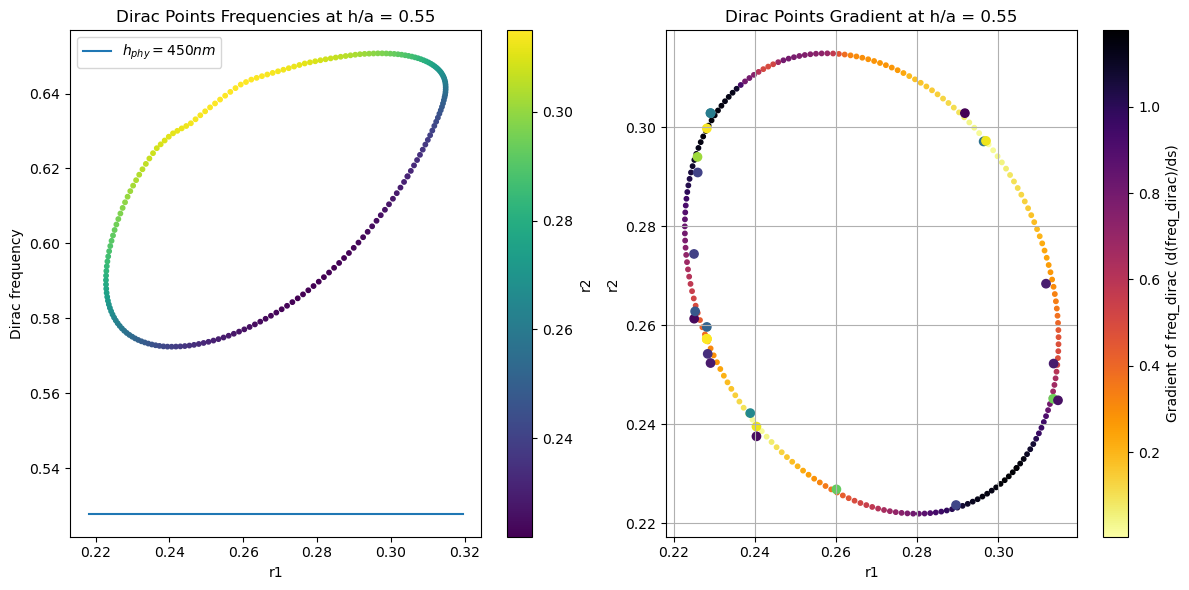

/tmp/ipykernel_2101539/1524669970.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


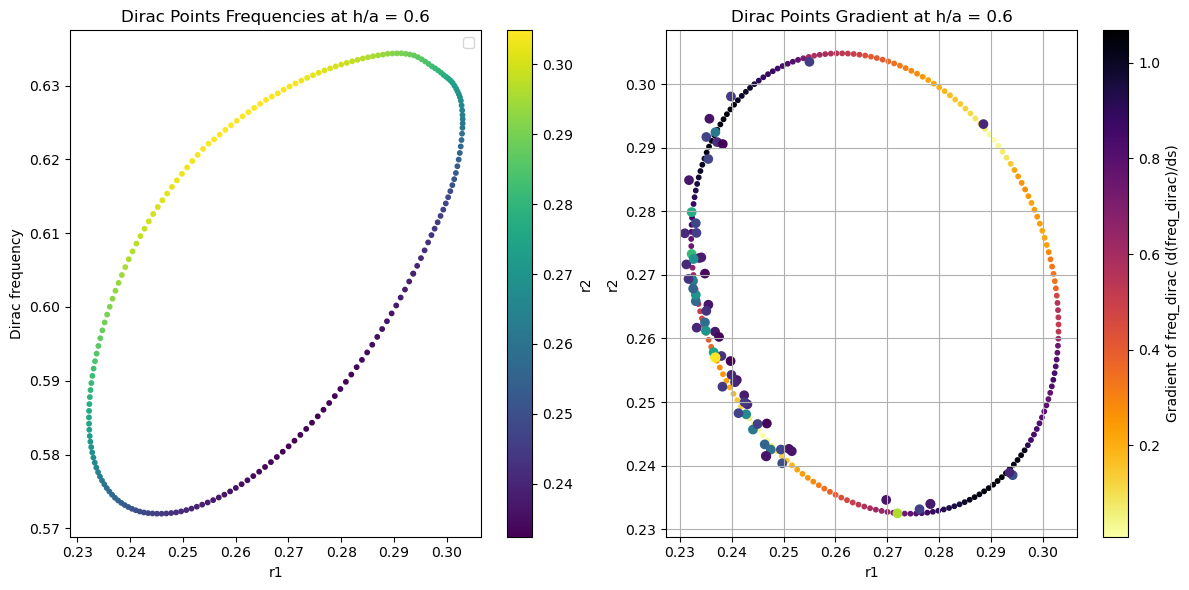

In [8]:
lambda0 = 1550
for h in h_array:
    figure_freq_dirac, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    plt.sca(axes[0])    
    path_data_opt = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_{h:0.3f}/{name_slab_opt}_p64_h_{h:0.3f}.de.data")
    analyzer = OptimizationDataAnalyzer(path_data_opt)
    x, y, f, aa = analyzer.compute_freq_dirac_along_ellipse(threshold=threshold)
    analyzer.plot_freq_dirac_along_ellipse(threshold=threshold)
    h_phy_array = [250, 275, 291,  300, 325, 330, 350,  375, 400, 425, 450]
    xlim = plt.xlim()
    ylim = plt.ylim()  
    for h_phy in h_phy_array:
        w_target = h_phy / lambda0/h
        if w_target < ylim[1]*1.1 and w_target > ylim[0]*0.9:   
            plt.plot(xlim, [w_target, w_target], label = f"$h_{{phy}} = {h_phy} nm$")
    plt.title(f"Dirac Points Frequencies at h/a = {h}")
    plt.legend()
    plt.grid()
    plt.xlabel("r1")
    plt.ylabel("Dirac frequency")
    colorbar = plt.colorbar() 
    colorbar.set_label("r2")   



    plt.sca(axes[1])
    analyzer.plot_gradient_along_ellipse(threshold=threshold, abs = True)
    points = analyzer.get_points_above_treshold(threshold)
    plt.scatter(points["r1"], points["r2"], c=1/points["cost"], cmap="viridis",
                norm=colors.LogNorm(vmin=(1/points["cost"]).min(), vmax=(1/points["cost"]).max()))
    plt.title(f"Dirac Points Gradient at h/a = {h}")
    plt.grid()
    plt.show()




In [25]:
r1 = 0.23
path_data_file = os.path.join(data_rooth, f"{name_slab_opt}_p64_h_0.350/{name_slab_opt}_p64_h_0.350.de.data")
analyzer = OptimizationDataAnalyzer(path_data_file)
r2 = analyzer.compute_param2_from_param1_on_ellipse(r1, threshold=1000, branch = "lower")
print(r2)


0.23965795349051427


In [26]:
# Instantiate the new sweeper
from src.lsf_sweeper import LSFSweeper
values = np.linspace(0.23, 0.25, 32, endpoint=True)
sweeper = LSFSweeper(simulation_slab_sweep.simulation_name, directory=simulation_slab_sweep.directory,
                     scheme_script=simulation_slab_sweep.script, 
                        param_name="r2", param_values=values,
                        polarization="zeven",
                        bands=[8,9,10],
                        others_command_line_params={"r1": 0.23, "h": 0.35},
                       )

# Run the sweeper
sweeper.submit_lsf_job(lsf_config)

LSF job script written to: /work3/s232699/phc_nzi/data/C4v_diatomic_slab_sweep/C4v_diatomic_slab_sweep.sh
Job submitted successfully. Submission output:
Job <24502309> is submitted to queue <fotonano>.

Waiting for job 24502309 to finish...
Job 24502309 status: PEND, elapsed time: 0 sec
Job 24502309 status: RUN, elapsed time: 10 sec
Job 24502309 status: RUN, elapsed time: 20 sec
Job 24502309 status: RUN, elapsed time: 30 sec
Job 24502309 status: RUN, elapsed time: 40 sec
Job 24502309 status: RUN, elapsed time: 50 sec
Job 24502309 status: RUN, elapsed time: 60 sec
Job 24502309 status: RUN, elapsed time: 70 sec
Job 24502309 status: RUN, elapsed time: 80 sec
Job 24502309 status: RUN, elapsed time: 90 sec
Job 24502309 status: RUN, elapsed time: 100 sec
Job 24502309 status: RUN, elapsed time: 110 sec
Job 24502309 status: RUN, elapsed time: 120 sec
Job 24502309 status: RUN, elapsed time: 130 sec
Job 24502309 status: RUN, elapsed time: 140 sec
Job 24502309 status: RUN, elapsed time: 150 sec
J

'Job <24502309> is submitted to queue <fotonano>.\n'

0.23 0.23965795349051427


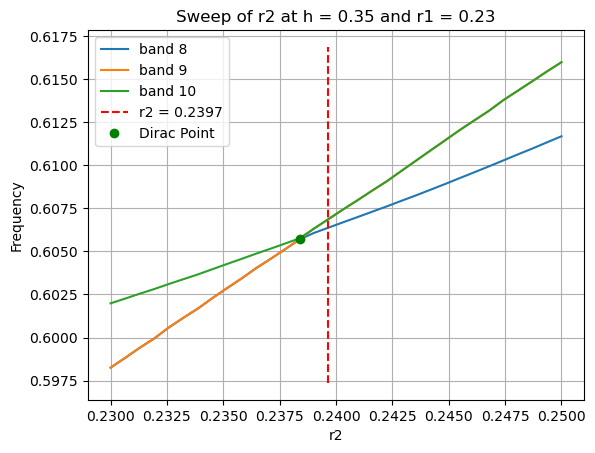

In [42]:
df = sweeper.load_results()
#display(df)
print(r1,r2)
plt.figure()
plt.plot(df["r2"], df["band_8"], label="band 8")
plt.plot(df["r2"], df["band_9"], label="band 9")
plt.plot(df["r2"], df["band_10"], label="band 10")

plt.grid()
plt.xlabel("r2")
plt.ylabel("Frequency")
ylim = plt.ylim()
plt.plot([r2, r2], ylim, "r--", label = f"r2 = {r2:0.4f}")
idx_freq_dirac = np.argmin(np.abs(df["band_10"] - df["band_8"]))
plt.plot(df["r2"][idx_freq_dirac], df["band_8"][idx_freq_dirac], "go", label = "Dirac Point")
plt.title(f"Sweep of r2 at h = 0.35 and r1 = {0.23}")
plt.legend()
plt.show()

